In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [145]:
from sklearn.datasets import make_classification
X,y=make_classification(n_features=10,n_samples=1000,n_classes=2,random_state=42)

In [146]:
pd.DataFrame(X)

,0,1,2,3,4,5,6,7,8,9
0,0.964799,-0.066449,0.986768,-0.358079,0.997266,1.181890,-1.615679,-1.210161,-0.628077,1.227274
1,-0.916511,-0.566395,-1.008614,0.831617,-1.176962,1.820544,1.752375,-0.984534,0.363896,0.209470
2,-0.109484,-0.432774,-0.457649,0.793818,-0.268646,-1.836360,1.239086,-0.246383,-1.058145,-0.297376
3,1.750412,2.023606,1.688159,0.006800,-1.607661,0.184741,-2.619427,-0.357445,-1.473127,-0.190039
4,-0.224726,-0.711303,-0.220778,0.117124,1.536061,0.597538,0.348645,-0.939156,0.175915,0.236224
...,...,...,...,...,...,...,...,...,...,...
995,-1.367638,1.462255,-1.154918,-0.290454,-0.413424,0.032396,1.545490,1.428760,1.687092,1.072542
996,-1.514876,-3.221016,-1.300744,0.395599,-0.527994,1.353069,1.777506,-1.680870,1.798510,0.034272
997,1.674633,1.754933,1.586154,0.018402,-1.514470,0.321593,-2.417694,0.692723,-1.503850,0.225264
998,-0.778609,-0.835689,-0.194842,1.097220,0.180071,-0.272933,-0.533188,-0.497354,2.472138,0.867187


In [147]:
pd.DataFrame(y)

,0
0,0
1,1
2,1
3,0
4,1
...,...
995,1
996,1
997,0
998,0


In [148]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30,random_state=15)

In [149]:
from sklearn.linear_model import LogisticRegression
logistic=LogisticRegression()


In [150]:
logistic.fit(X_train,y_train)

LogisticRegression()

In [151]:
y_pred=logistic.predict(X_test)
y_pred

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1])

In [152]:
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix
score=accuracy_score(y_test,y_pred)

metrix=confusion_matrix(y_test,y_pred)

classification_report=classification_report(y_test,y_pred)

print(score)
print(metrix)
print(classification_report)

0.8333333333333334
[[128  30]
 [ 20 122]]
              precision    recall  f1-score   support

           0       0.86      0.81      0.84       158
           1       0.80      0.86      0.83       142

    accuracy                           0.83       300
   macro avg       0.83      0.83      0.83       300
weighted avg       0.84      0.83      0.83       300



## Hyperparameter tuning for cross validation

## Grid Search CV

In [153]:
model=LogisticRegression()
penalty=['l1', 'l2', 'elasticnet']
c_values=[100,0.1,1.0,10,0.01] 
solver=['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']

params=dict(penalty=penalty,C=c_values,solver=solver)

In [154]:
from sklearn.model_selection import StratifiedKFold
cv=StratifiedKFold()

In [155]:
from sklearn.model_selection import GridSearchCV
grid=GridSearchCV(estimator=model,cv=cv,param_grid=params,scoring='accuracy',n_jobs=-1)
grid

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [100, 0.1, 1.0, 10, 0.01],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['lbfgs', 'liblinear', 'newton-cg',
                                    'newton-cholesky', 'sag', 'saga']},
             scoring='accuracy')

In [156]:
grid.fit(X_train,y_train)

d:\DataScience\vern\lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
250 fits failed out of a total of 450.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "d:\DataScience\vern\lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "d:\DataScience\vern\lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "d:\DataScience\vern\lib\site-packages\sklearn\linear_model\_logistic.py", line 1193, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
  File "d:\DataSc

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [100, 0.1, 1.0, 10, 0.01],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['lbfgs', 'liblinear', 'newton-cg',
                                    'newton-cholesky', 'sag', 'saga']},
             scoring='accuracy')

In [157]:
grid.best_params_

{'C': 0.1, 'penalty': 'l1', 'solver': 'saga'}

In [158]:
y_pred=grid.predict(X_test)

In [159]:
score=accuracy_score(y_test,y_pred)
print(score)

0.85


## Randomized CV

In [160]:
from sklearn.model_selection import RandomizedSearchCV

model=LogisticRegression()
randomized=RandomizedSearchCV(estimator=model,cv=5,scoring='accuracy',param_distributions=params)


In [161]:
randomized.fit(X_train,y_train)


d:\DataScience\vern\lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
30 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "d:\DataScience\vern\lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "d:\DataScience\vern\lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "d:\DataScience\vern\lib\site-packages\sklearn\linear_model\_logistic.py", line 1193, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
  File "d:\DataScien

RandomizedSearchCV(cv=5, estimator=LogisticRegression(),
                   param_distributions={'C': [100, 0.1, 1.0, 10, 0.01],
                                        'penalty': ['l1', 'l2', 'elasticnet'],
                                        'solver': ['lbfgs', 'liblinear',
                                                   'newton-cg',
                                                   'newton-cholesky', 'sag',
                                                   'saga']},
                   scoring='accuracy')

In [162]:
randomized.best_params_

{'solver': 'sag', 'penalty': 'l2', 'C': 10}

In [163]:
y_pred=randomized.predict(X_test)

In [164]:
score=accuracy_score(y_test,y_pred)
print(score)

0.8333333333333334


## Logistic regression for multiclass classification

In [165]:
X,y=make_classification(n_samples=1000,n_features=10,n_informative=3,n_classes=3,random_state=32)

In [166]:
y

array([2, 1, 1, 2, 1, 0, 2, 0, 2, 0, 2, 2, 0, 2, 2, 0, 2, 0, 2, 1, 2, 1,
       2, 1, 0, 1, 0, 2, 2, 1, 2, 0, 0, 1, 1, 0, 1, 1, 2, 1, 0, 0, 0, 0,
       0, 0, 1, 2, 2, 1, 1, 0, 1, 1, 0, 1, 1, 1, 2, 2, 1, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 2, 2, 1, 2, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 2,
       1, 1, 0, 0, 2, 2, 1, 1, 1, 0, 1, 2, 0, 1, 0, 2, 0, 0, 0, 0, 1, 0,
       2, 1, 0, 1, 0, 0, 0, 0, 1, 2, 1, 1, 0, 1, 2, 0, 2, 1, 1, 0, 1, 2,
       1, 0, 2, 2, 0, 2, 0, 2, 0, 0, 1, 1, 0, 1, 2, 0, 2, 1, 0, 2, 0, 0,
       0, 2, 2, 2, 1, 2, 1, 2, 0, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       2, 0, 0, 2, 2, 0, 1, 0, 0, 0, 0, 0, 0, 2, 1, 0, 0, 1, 2, 1, 0, 2,
       0, 1, 1, 2, 2, 0, 1, 2, 2, 0, 0, 2, 1, 2, 2, 1, 2, 1, 1, 1, 1, 0,
       2, 1, 1, 1, 2, 1, 1, 0, 0, 0, 0, 0, 2, 0, 2, 1, 1, 2, 2, 2, 0, 1,
       2, 2, 0, 1, 2, 0, 1, 1, 0, 0, 0, 1, 2, 1, 1, 1, 2, 0, 2, 0, 1, 2,
       1, 2, 1, 1, 1, 1, 2, 0, 2, 1, 2, 0, 2, 0, 1, 2, 2, 0, 0, 2, 1, 1,
       0, 0, 2, 2, 0, 2, 0, 2, 0, 1, 1, 0, 1, 2, 0,

In [167]:
X

array([[-0.39060021,  0.69021332,  0.2213342 , ..., -0.3591415 ,
        -0.94761357, -1.80170772],
       [ 2.69351286, -0.87558537,  0.1401227 , ...,  0.68815057,
        -3.3941774 , -2.22939532],
       [-1.6941434 ,  0.22153849,  2.20117969, ...,  0.01214509,
         2.67134443,  0.21563146],
       ...,
       [ 0.39901046,  0.107561  ,  1.3629292 , ...,  1.06745205,
         1.66953305,  2.33804365],
       [ 0.93119603,  0.25038621,  0.12217122, ..., -0.68737106,
         1.29423549,  2.15811914],
       [ 0.73889123,  0.96508255,  0.93333498, ...,  1.42031256,
         1.07685491,  2.49558954]])

In [168]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [169]:
multi=LogisticRegression(multi_class='ovr')
multi.fit(X_train,y_train)

d:\DataScience\vern\lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='ovr')

In [170]:
y_pred=multi.predict(X_test)

In [171]:
y_pred

array([0, 2, 2, 0, 2, 1, 0, 2, 0, 0, 2, 1, 0, 0, 2, 2, 1, 2, 2, 0, 0, 2,
       2, 2, 1, 0, 1, 2, 0, 0, 0, 2, 0, 0, 2, 0, 1, 1, 0, 2, 1, 2, 1, 2,
       1, 0, 2, 2, 2, 2, 2, 2, 0, 1, 1, 2, 1, 2, 2, 0, 1, 0, 2, 2, 0, 2,
       0, 1, 2, 1, 0, 0, 2, 0, 0, 2, 2, 2, 0, 2, 0, 2, 0, 2, 0, 1, 2, 2,
       2, 1, 2, 2, 0, 2, 0, 0, 0, 2, 0, 2, 1, 1, 2, 1, 1, 2, 2, 2, 0, 2,
       2, 0, 2, 0, 0, 2, 0, 1, 1, 0, 0, 0, 1, 2, 1, 2, 2, 1, 1, 2, 2, 0,
       0, 0, 0, 0, 2, 2, 0, 2, 0, 0, 2, 0, 0, 2, 0, 0, 1, 0, 2, 1, 1, 2,
       1, 0, 0, 2, 2, 0, 1, 2, 1, 0, 0, 2, 1, 0, 1, 2, 2, 1, 0, 0, 2, 1,
       1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 2, 0, 0, 0, 2, 2, 2, 1, 2, 1, 2, 0,
       2, 0, 2, 2, 0, 0, 0, 1, 2, 2, 1, 0, 2, 0, 2, 0, 2, 0, 2, 2, 2, 2,
       1, 1, 2, 2, 1, 2, 1, 0, 2, 0, 2, 0, 2, 0, 2, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 2, 0, 0, 0, 2, 0])

In [172]:
score=accuracy_score(y_pred,y_test)
print(score)
print(confusion_matrix(y_pred,y_test))

0.584
[[75 12 10]
 [ 6 25 22]
 [ 4 50 46]]


## Logistic regression for imbalanced dataset

In [173]:
from collections import Counter

Created a dataset where it contains 1000 samples where there are 9:1 ratio of features

In [174]:
X,y=make_classification(n_samples=1000,n_features=2,n_clusters_per_class=1,n_redundant=0,weights=[0.99],random_state=42)

In [175]:
X

array([[ 1.0735459 , -1.10133925],
       [ 0.75594526, -1.1723519 ],
       [ 1.35447877, -0.94852841],
       ...,
       [-2.15090138, -2.98937226],
       [ 2.45164689, -0.1566294 ],
       [ 3.64147835,  0.75692519]])

In [176]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [177]:
Counter(y)

Counter({np.int64(0): 985, np.int64(1): 15})

<Axes: >

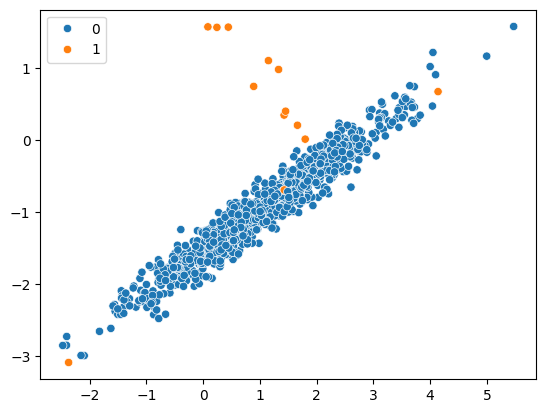

In [178]:
import pandas as pd
import seaborn as sns

sns.scatterplot(x=X[:, 0],y=X[:, 1],hue=y)

In [179]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [180]:
model=LogisticRegression()
penalty=['l1', 'l2', 'elasticnet']
solver=['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']
C=[0.1,1.0,10,100,0.01]
class_weight=[{0:w,1:y} for w in [1,10,50,100] for y in [1,10,50,100]]


In [181]:
params=dict(penalty=penalty,solver=solver,C=C,class_weight=class_weight)

In [182]:
cv=StratifiedKFold()
grid=GridSearchCV(estimator=model,param_grid=params,scoring='accuracy',cv=cv)

In [183]:
grid.fit(X_train,y_train)

d:\DataScience\vern\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\DataScience\vern\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\DataScience\vern\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\DataScience\vern\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\DataScience\vern\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\DataScience\vern\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the co

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LogisticRegression(),
             param_grid={'C': [0.1, 1.0, 10, 100, 0.01],
                         'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 10},
                                          {0: 1, 1: 50}, {0: 1, 1: 100},
                                          {0: 10, 1: 1}, {0: 10, 1: 10},
                                          {0: 10, 1: 50}, {0: 10, 1: 100},
                                          {0: 50, 1: 1}, {0: 50, 1: 10},
                                          {0: 50, 1: 50}, {0: 50, 1: 100},
                                          {0: 100, 1: 1}, {0: 100, 1: 10},
                                          {0: 100, 1: 50}, {0: 100, 1: 100}],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['lbfgs', 'liblinear', 'newton-cg',
                                    'newton-cholesky', 'sag', 'saga']},
             scoring='accuracy')

In [184]:
grid.best_params_

{'C': 0.1,
 'class_weight': {0: 10, 1: 100},
 'penalty': 'l1',
 'solver': 'liblinear'}

In [185]:
y_pred=grid.predict(X_test)

In [186]:
score=accuracy_score(y_pred,y_test)
print(score)

print(confusion_matrix(y_pred,y_test))

0.996
[[247   1]
 [  0   2]]


### Logistic Regression with ROC curve and ROC AUC score

In [187]:
from sklearn.datasets import make_classification
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.model_selection import train_test_split


In [188]:
X ,y=make_classification(n_samples=1000,n_classes=2,random_state=1)

In [189]:
X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=0.25,random_state=42)


In [190]:
model=LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [191]:
# Created a dummy model with default 0 as output 
dummy_model_prob = [0 for _ in range(len(y_test))]
dummy_model_prob

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

In [192]:
model_prob=model.predict_proba(X_test)

In [193]:
model_prob

array([[9.58775327e-04, 9.99041225e-01],
       [9.03113399e-01, 9.68866009e-02],
       [5.10627964e-01, 4.89372036e-01],
       [1.89953026e-01, 8.10046974e-01],
       [8.87573193e-01, 1.12426807e-01],
       [5.60127995e-01, 4.39872005e-01],
       [1.70539186e-01, 8.29460814e-01],
       [2.86177560e-01, 7.13822440e-01],
       [1.12292117e-01, 8.87707883e-01],
       [1.32026145e-01, 8.67973855e-01],
       [9.99456145e-01, 5.43854787e-04],
       [1.68799639e-01, 8.31200361e-01],
       [8.08969781e-01, 1.91030219e-01],
       [4.60946921e-01, 5.39053079e-01],
       [2.71939746e-01, 7.28060254e-01],
       [1.76492952e-01, 8.23507048e-01],
       [6.14129577e-02, 9.38587042e-01],
       [3.61632696e-01, 6.38367304e-01],
       [8.89840189e-01, 1.10159811e-01],
       [7.58965653e-01, 2.41034347e-01],
       [9.88414268e-01, 1.15857322e-02],
       [5.09845298e-01, 4.90154702e-01],
       [1.11914893e-01, 8.88085107e-01],
       [2.05189797e-03, 9.97948102e-01],
       [8.630545

In [194]:
model_prob=model_prob[:,1]

In [195]:
model_prob

array([9.99041225e-01, 9.68866009e-02, 4.89372036e-01, 8.10046974e-01,
       1.12426807e-01, 4.39872005e-01, 8.29460814e-01, 7.13822440e-01,
       8.87707883e-01, 8.67973855e-01, 5.43854787e-04, 8.31200361e-01,
       1.91030219e-01, 5.39053079e-01, 7.28060254e-01, 8.23507048e-01,
       9.38587042e-01, 6.38367304e-01, 1.10159811e-01, 2.41034347e-01,
       1.15857322e-02, 4.90154702e-01, 8.88085107e-01, 9.97948102e-01,
       1.36945498e-01, 1.32643249e-02, 6.45087847e-01, 9.69507009e-01,
       3.99070556e-02, 2.38152731e-02, 3.69213417e-01, 3.40314906e-02,
       2.29858043e-01, 9.57101721e-01, 5.44958479e-01, 6.56791269e-01,
       1.52123558e-02, 2.93410161e-02, 7.80393330e-01, 2.99088014e-02,
       9.28398422e-01, 8.43395917e-01, 1.60117892e-02, 5.78395703e-04,
       6.61496895e-02, 6.69762422e-02, 9.97948178e-01, 6.55755704e-01,
       8.94036983e-01, 6.07000680e-02, 2.10340754e-02, 3.23954283e-02,
       1.03560315e-01, 5.44021349e-02, 5.64730236e-01, 9.87033757e-01,
      

In [196]:
## Calculating dummy roc auc score and model roc auc score

dummy_rocaucscore=roc_auc_score(y_test,dummy_model_prob)
model_rocaucscore=roc_auc_score(y_test,model_prob)
print(dummy_rocaucscore)
print(model_rocaucscore)

0.5
0.9108885464817668


In [197]:
dummy_fpr,dummy_tpr,_=roc_curve(y_test,dummy_model_prob)
model_fpr,model_tpr,threshold=roc_curve(y_test,model_prob)

In [198]:
model_tpr,model_fpr

(array([0.        , 0.00847458, 0.1440678 , 0.1440678 , 0.23728814,
        0.23728814, 0.28813559, 0.28813559, 0.36440678, 0.36440678,
        0.37288136, 0.37288136, 0.43220339, 0.43220339, 0.55084746,
        0.55084746, 0.60169492, 0.60169492, 0.6440678 , 0.6440678 ,
        0.6779661 , 0.6779661 , 0.68644068, 0.68644068, 0.69491525,
        0.69491525, 0.70338983, 0.70338983, 0.74576271, 0.74576271,
        0.79661017, 0.79661017, 0.81355932, 0.81355932, 0.83050847,
        0.83050847, 0.84745763, 0.84745763, 0.86440678, 0.86440678,
        0.88135593, 0.88135593, 0.88983051, 0.88983051, 0.89830508,
        0.89830508, 0.92372881, 0.92372881, 0.93220339, 0.93220339,
        0.94067797, 0.94067797, 0.95762712, 0.95762712, 0.96610169,
        0.96610169, 0.97457627, 0.97457627, 0.98305085, 0.98305085,
        1.        , 1.        ]),
 array([0.        , 0.        , 0.        , 0.00757576, 0.00757576,
        0.01515152, 0.01515152, 0.02272727, 0.02272727, 0.03030303,
        0.0303

In [199]:
threshold

array([           inf, 9.99738397e-01, 9.87033757e-01, 9.86362468e-01,
       9.57744551e-01, 9.57101721e-01, 9.45385188e-01, 9.40463485e-01,
       9.28300276e-01, 9.27356342e-01, 9.25607881e-01, 9.23728474e-01,
       8.94744248e-01, 8.94036983e-01, 8.43395917e-01, 8.38396411e-01,
       8.28791784e-01, 8.26684852e-01, 8.08489957e-01, 8.06352720e-01,
       7.80393330e-01, 7.63976766e-01, 7.63705186e-01, 7.63537905e-01,
       7.58496683e-01, 7.55347574e-01, 7.52623720e-01, 7.48020931e-01,
       7.23488083e-01, 7.23238629e-01, 6.74619385e-01, 6.56791269e-01,
       6.55162225e-01, 6.26882105e-01, 5.99962989e-01, 5.57931518e-01,
       5.39053079e-01, 5.14219160e-01, 5.05342549e-01, 4.96278090e-01,
       4.90154702e-01, 4.85201910e-01, 4.69275954e-01, 4.50983178e-01,
       4.46563018e-01, 4.39872005e-01, 4.24245353e-01, 3.24715881e-01,
       3.12906913e-01, 3.06694053e-01, 3.01325247e-01, 2.10358834e-01,
       2.06296724e-01, 1.91030219e-01, 1.69877066e-01, 1.42771985e-01,
      

In [200]:
import seaborn as sns
from matplotlib import pyplot

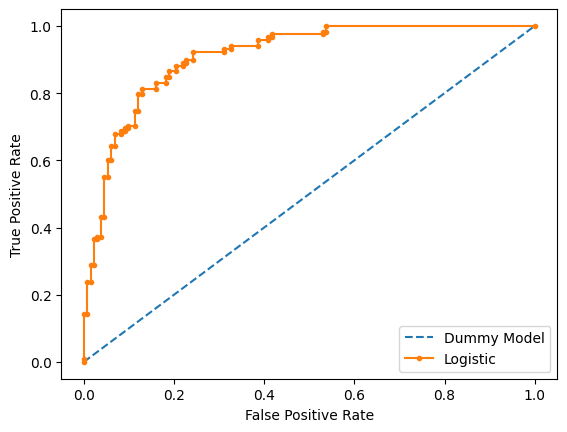

In [206]:
# plot the roc curve for the model
pyplot.plot(dummy_fpr, dummy_tpr, linestyle='--', label='Dummy Model')
pyplot.plot(model_fpr, model_tpr, marker='.', label='Logistic')
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
# show the plot
pyplot.show()

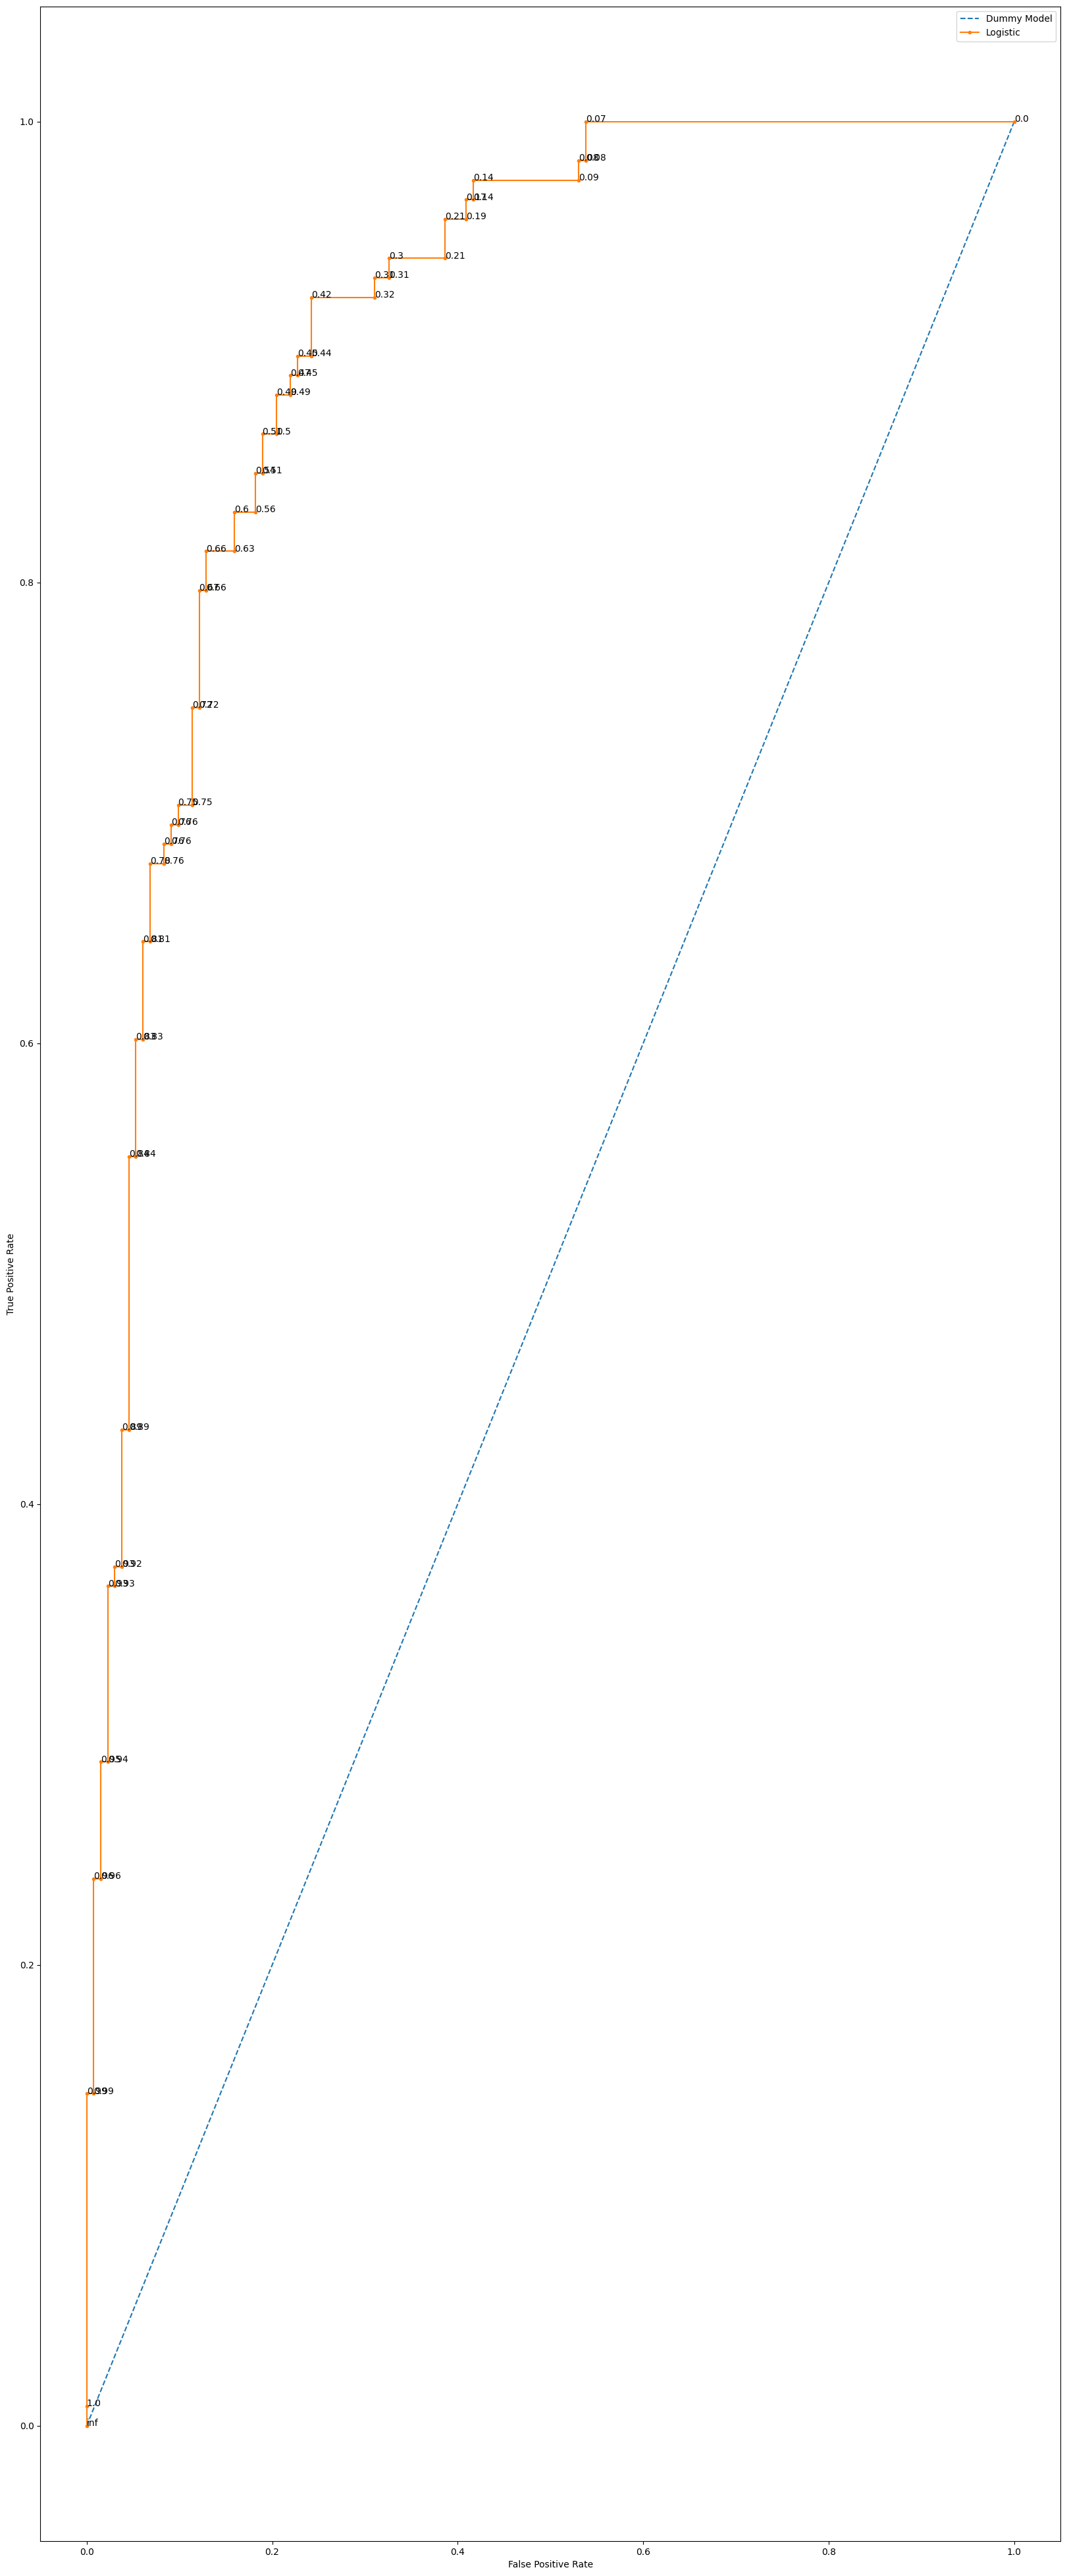

In [215]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(20,50))

# Plot ROC curves
ax.plot(dummy_fpr, dummy_tpr, linestyle='--', label='Dummy Model')
ax.plot(model_fpr, model_tpr, marker='.', label='Logistic')

# Annotate thresholds
for fpr, tpr, thr in zip(model_fpr, model_tpr, threshold):
    ax.annotate(str(np.round(thr, 2)), (fpr, tpr))

# Labels
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')

# Legend
ax.legend()

plt.show()


## From the above conclusion we can select the threshold according to the domain expert 
## For example if the domain expert want flase positive rate to be low and tru positive rate to be high the we can search the threshold accordingly in the graph and set it 
